# Notebook 0: Exploratory Data Analysis
Understanding the raw fitness dataset before modeling.
Explores workout patterns, user behavior, and factors influencing calories burned.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('src/data/gym_members_exercise_tracking.csv')
print(df.shape)
print(df.dtypes)
print(df.head())

(973, 15)
Age                                int64
Gender                               str
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                         str
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object
   Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0   56    Male         88.3        1.71      180      157           60   
1   46  Female         74.9        1.53      179      151           66   
2   32  Female         68.1        1.66      167      122           54   
3   25    Male         53.2        1.70      190      164        

## Which workouts burn the most calories?

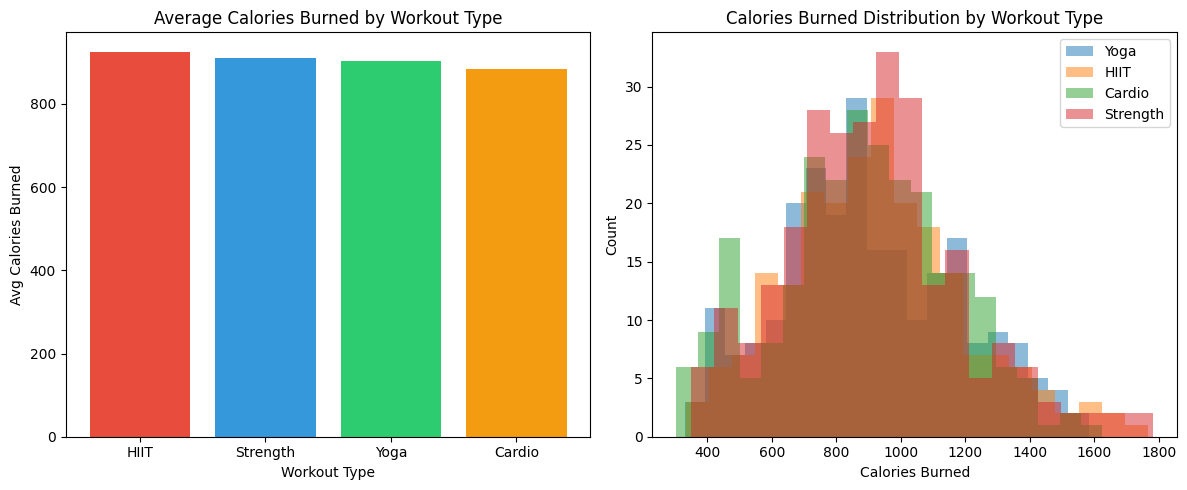

Workout_Type
HIIT        925.805430
Strength    910.697674
Yoga        903.188285
Cardio      884.513725
Name: Calories_Burned, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Average calories by workout type
avg_calories = df.groupby('Workout_Type')['Calories_Burned'].mean().sort_values(ascending=False)
axes[0].bar(avg_calories.index, avg_calories.values, color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])
axes[0].set_title('Average Calories Burned by Workout Type')
axes[0].set_xlabel('Workout Type')
axes[0].set_ylabel('Avg Calories Burned')

# Distribution of calories by workout type
for workout in df['Workout_Type'].unique():
    subset = df[df['Workout_Type'] == workout]['Calories_Burned']
    axes[1].hist(subset, alpha=0.5, label=workout, bins=20)
axes[1].set_title('Calories Burned Distribution by Workout Type')
axes[1].set_xlabel('Calories Burned')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('src/data/calories_by_workout.png', dpi=150)
plt.show()
print(avg_calories)

## Do advanced users behave differently?
Experience Level: 1 = Beginner, 2 = Intermediate, 3 = Advanced

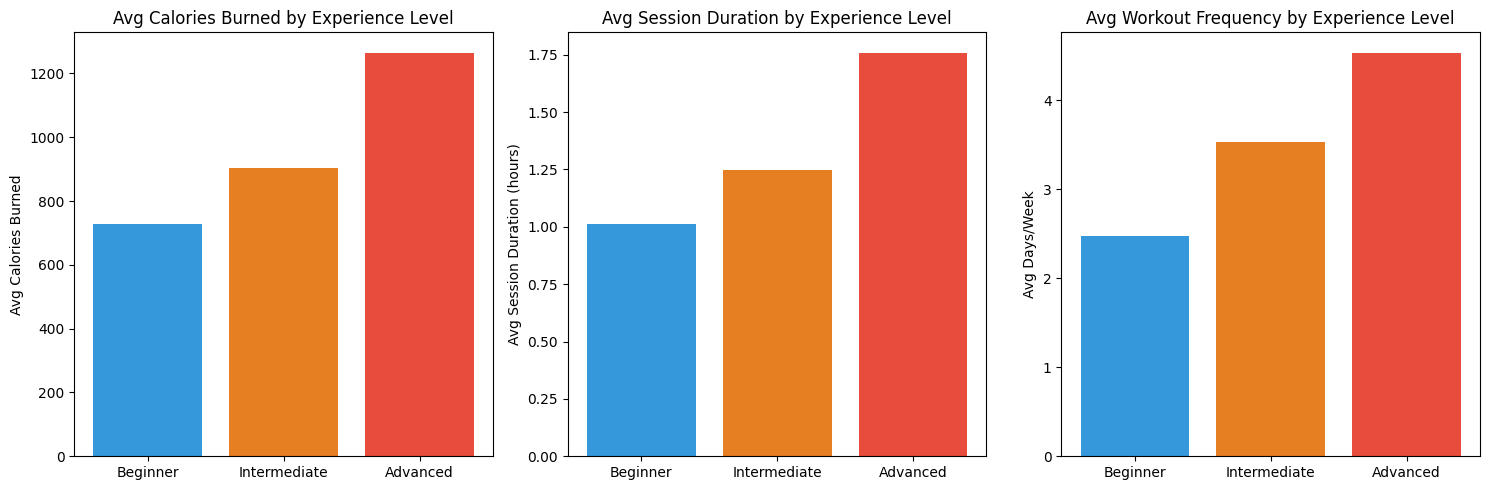

Calories by experience:
 [ 726.375       901.91871921 1265.34031414]
Session duration by experience:
 [1.01021277 1.24788177 1.75926702]
Frequency by experience:
 [2.47606383 3.53448276 4.53403141]


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Calories burned by experience level
avg_cal_exp = df.groupby('Experience_Level')['Calories_Burned'].mean()
axes[0].bar(['Beginner', 'Intermediate', 'Advanced'], avg_cal_exp.values, color=['#3498db', '#e67e22', '#e74c3c'])
axes[0].set_title('Avg Calories Burned by Experience Level')
axes[0].set_ylabel('Avg Calories Burned')

# Session duration by experience level
avg_dur_exp = df.groupby('Experience_Level')['Session_Duration (hours)'].mean()
axes[1].bar(['Beginner', 'Intermediate', 'Advanced'], avg_dur_exp.values, color=['#3498db', '#e67e22', '#e74c3c'])
axes[1].set_title('Avg Session Duration by Experience Level')
axes[1].set_ylabel('Avg Session Duration (hours)')

# Workout frequency by experience level
avg_freq_exp = df.groupby('Experience_Level')['Workout_Frequency (days/week)'].mean()
axes[2].bar(['Beginner', 'Intermediate', 'Advanced'], avg_freq_exp.values, color=['#3498db', '#e67e22', '#e74c3c'])
axes[2].set_title('Avg Workout Frequency by Experience Level')
axes[2].set_ylabel('Avg Days/Week')

plt.tight_layout()
plt.savefig('src/data/experience_behavior.png', dpi=150)
plt.show()

print("Calories by experience:\n", avg_cal_exp.values)
print("Session duration by experience:\n", avg_dur_exp.values)
print("Frequency by experience:\n", avg_freq_exp.values)

## Which workouts are popular among younger users?
Age groups: Under 30, 30-45, Over 45

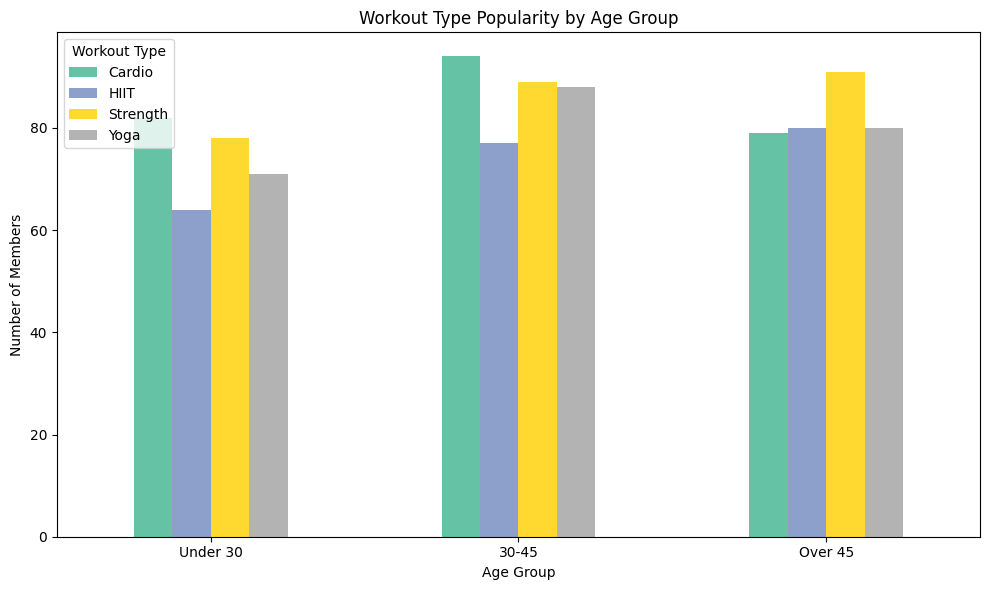

Workout_Type  Cardio  HIIT  Strength  Yoga
Age_Group                                 
Under 30          82    64        78    71
30-45             94    77        89    88
Over 45           79    80        91    80


In [5]:
# Create age groups
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 45, 100], labels=['Under 30', '30-45', 'Over 45'])

age_workout = df.groupby(['Age_Group', 'Workout_Type']).size().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
age_workout.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Workout Type Popularity by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Number of Members')
ax.legend(title='Workout Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('src/data/workout_by_age.png', dpi=150)
plt.show()

print(age_workout)

## What factors influence calories burned?
Correlation analysis across all numerical features.

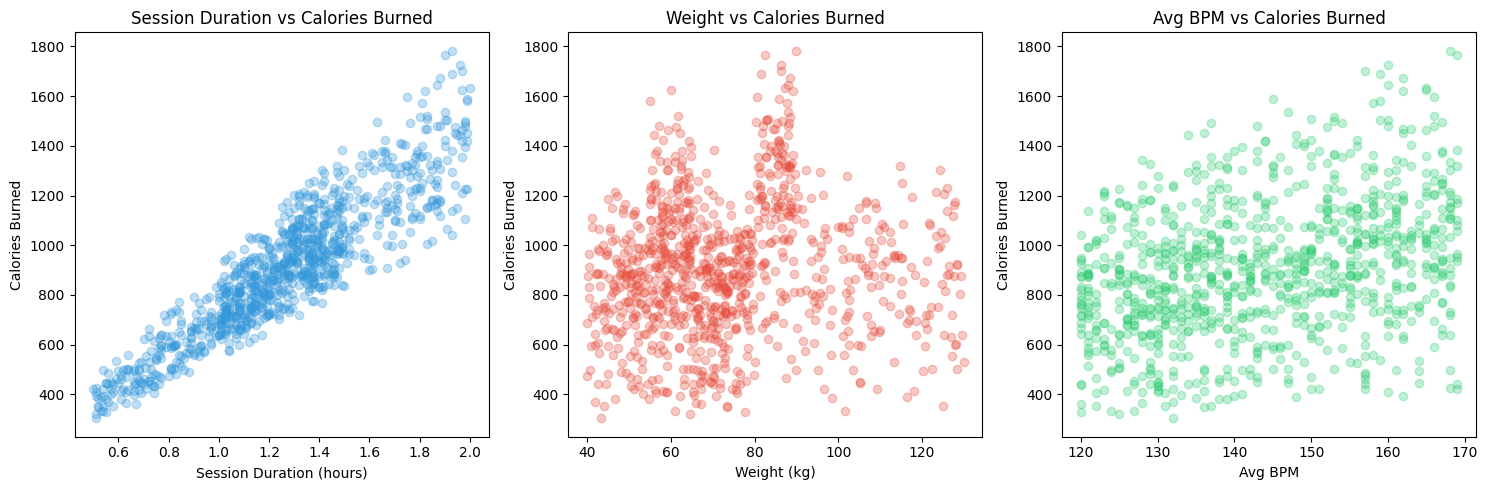

Correlation with Calories Burned:
Calories_Burned                  1.000
Session_Duration (hours)         0.908
Experience_Level                 0.694
Workout_Frequency (days/week)    0.576
Avg_BPM                          0.340
Weight (kg)                      0.095
Age                             -0.155
Name: Calories_Burned, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Session duration vs calories
axes[0].scatter(df['Session_Duration (hours)'], df['Calories_Burned'], alpha=0.3, color='#3498db')
axes[0].set_title('Session Duration vs Calories Burned')
axes[0].set_xlabel('Session Duration (hours)')
axes[0].set_ylabel('Calories Burned')

# Weight vs calories
axes[1].scatter(df['Weight (kg)'], df['Calories_Burned'], alpha=0.3, color='#e74c3c')
axes[1].set_title('Weight vs Calories Burned')
axes[1].set_xlabel('Weight (kg)')
axes[1].set_ylabel('Calories Burned')

# Avg BPM vs calories
axes[2].scatter(df['Avg_BPM'], df['Calories_Burned'], alpha=0.3, color='#2ecc71')
axes[2].set_title('Avg BPM vs Calories Burned')
axes[2].set_xlabel('Avg BPM')
axes[2].set_ylabel('Calories Burned')

plt.tight_layout()
plt.savefig('src/data/calories_factors.png', dpi=150)
plt.show()

# Correlation table
numeric_cols = ['Age', 'Weight (kg)', 'Session_Duration (hours)', 
                'Avg_BPM', 'Calories_Burned', 'Workout_Frequency (days/week)', 
                'Experience_Level']
corr = df[numeric_cols].corr()['Calories_Burned'].sort_values(ascending=False)
print("Correlation with Calories Burned:")
print(corr.round(3))

## Key Findings
- **HIIT** burns the most calories on average, followed closely by Strength
- **Advanced users** burn 74% more calories than beginners, train 73% longer, and visit 83% more frequently
- **HIIT grows more popular with age** — most popular workout for Over 45 group
- **Session duration** is the strongest predictor of calories burned (r=0.91)
- **Experience level** is the second strongest predictor (r=0.69), more than weight or age

## Recommendation System Motivation
Understanding why collaborative filtering is the right approach for this dataset.

In [7]:
# How sparse is the interaction matrix?
num_users = df['Age'].count()  # using row count as proxy for unique users
num_items = df['Workout_Type'].nunique()
num_interactions = len(df)

sparsity = 1 - (num_interactions / (num_users * num_items))
print(f"Users:        {num_users}")
print(f"Workout types: {num_items}")
print(f"Interactions: {num_interactions}")
print(f"Sparsity:     {sparsity:.2%}")

Users:        973
Workout types: 4
Interactions: 973
Sparsity:     75.00%


## Do users stick to one workout type or try multiple?
If users only do one workout type, personalization matters — we can't just recommend the most popular one.

Workouts per user:
Workout_Type
1    973
Name: count, dtype: int64

Workout popularity (%):
Workout_Type
Strength    26.5
Cardio      26.2
Yoga        24.6
HIIT        22.7
Name: proportion, dtype: float64


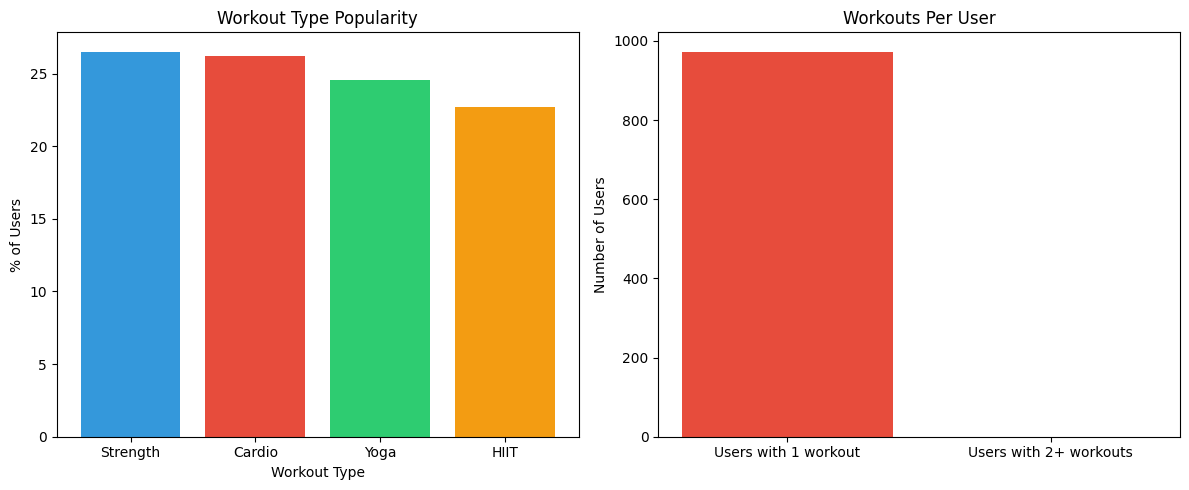

In [8]:
workouts_per_user = df.groupby(df.index)['Workout_Type'].count()
print("Workouts per user:")
print(workouts_per_user.value_counts())

# Workout type popularity
popularity = df['Workout_Type'].value_counts(normalize=True) * 100
print("\nWorkout popularity (%):")
print(popularity.round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(popularity.index, popularity.values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[0].set_title('Workout Type Popularity')
axes[0].set_xlabel('Workout Type')
axes[0].set_ylabel('% of Users')

# Show that each user only has one workout — personalization is needed
axes[1].bar(['Users with 1 workout', 'Users with 2+ workouts'], 
            [len(df), 0], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Workouts Per User')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.savefig('src/data/popularity_bias.png', dpi=150)
plt.show()

## Is there a popularity bias?
If one workout dominates, a simple popularity-based recommender would work fine.
Near-uniform distribution means we need personalization — a popularity baseline won't cut it.

In [9]:
# Compare what a popularity baseline would recommend vs actual distribution
most_popular = df['Workout_Type'].value_counts().index[0]
popularity_accuracy = df['Workout_Type'].value_counts(normalize=True).max() * 100

print(f"Most popular workout: {most_popular}")
print(f"A popularity baseline would be correct only {popularity_accuracy:.1f}% of the time")
print(f"Near-uniform distribution means personalization is essential")

# Show implicit feedback distribution
feedback = df['Workout_Frequency (days/week)'].apply(lambda x: 1 if x >= 4 else 0)
print(f"\nImplicit feedback (frequency >= 4 days/week):")
print(feedback.value_counts())
print(f"Positive signal rate: {feedback.mean():.1%}")

Most popular workout: Strength
A popularity baseline would be correct only 26.5% of the time
Near-uniform distribution means personalization is essential

Implicit feedback (frequency >= 4 days/week):
Workout_Frequency (days/week)
0    565
1    408
Name: count, dtype: int64
Positive signal rate: 41.9%


## Summary — Why NCF?
- Interaction matrix is 75% sparse — standard for collaborative filtering
- Every user has exactly one workout type — personalization is essential
- Popularity baseline would only be correct 26.5% of the time
- Near-uniform workout distribution means no single workout dominates
- 41.9% positive implicit feedback signal — reasonable for a binary interaction model